In [1]:
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import pairwise_logrank_test
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from skbio.stats.composition import clr
from sklearn.preprocessing import normalize
from sklearn.utils import resample
import time

import warnings
warnings.filterwarnings("ignore", message="FutureWarning")

import sys

main_path = '/Users/Kai/HPL-LATTICeA'
sys.path.append(main_path)
from libraries.survival import *
from libraries.clinical import load_clinical
from libraries.data_processing import *
from libraries.forest_plots import *
from libraries.supercluster_dictionary import assign_supercluster

In [2]:
meta_folder        = 'rapids_2p5m'
matching_field     = 'samples'
event_ind_field    = 'os_event_ind'
event_data_field   = 'os_event_data'
diversity_key      = None
type_composition   = 'clr'
min_tiles          = 100
folds_pickle       = os.path.join(main_path, 'utilities/fold_creation/lattice_5x_folds.pkl')
force_fold         = 2
h5_complete_path   = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_LATTICeA_5x_he_complete_filtered.h5')
h5_additional_path = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_TCGA_LUAD_5x_he_train_filtered.h5')
additional_as_fold = False
report_clusters    = False

max_months        = 60
use_conn          = False
use_ratio         = False
top_variance_feat = 99

l1_ratios   = [0.0]
if len(l1_ratios) == 1:
    l1_ratio = l1_ratios[0]
    
resolutions = [2.5]
if len(resolutions) == 1:
    resolution = resolutions[0]

main_cluster_path = h5_complete_path.split('hdf5_')[0]
main_cluster_path = os.path.join(main_path, main_cluster_path, meta_folder)
adatas_path       = os.path.join(main_cluster_path, 'adatas')

print(main_path)
print(main_cluster_path)
print(adatas_path)

/Users/Kai/HPL-LATTICeA
/Users/Kai/HPL-LATTICeA/results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/rapids_2p5m
/Users/Kai/HPL-LATTICeA/results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/rapids_2p5m/adatas


In [3]:
# Feature selection
leiden_clusters, malignant_clusters, stromal_clusters = load_topography(main_path=main_path)

# Get clinical data
clinpath, survival, patterns_samples = load_clinical(main_path=main_path)
survival = survival.merge(patterns_samples[['samples', 'iaslc_grade']], on='samples')
survival

/Users/Kai/HPL-LATTICeA/libraries/clinical.py:8: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD-LATTICeA/latticea_master_clinicopathological.csv'))
/Users/Kai/HPL-LATTICeA/libraries/clinical.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

,index,sample_ID,Originator,Checked,Pathology Number,Case Number,male,Complete?,Receipt Delay (Days),age,...,Invasion.10,Donor Block Number.11,Core Row.11,Core Column.11,Invasion.11,Complete?.6,samples,stage_num,PDL_positive,iaslc_grade
0,11,13,ms831,crs20,PR022438N/10,2,0,Incomplete,0,76,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0002,1,NaN,3
1,253,14,ms831,crs20,PR025028M/10,3,1,Incomplete,1,77,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0003,1,0.0,2
2,14,18,ms831,crs20,PR026550L/10,4,0,Incomplete,1,61,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0004,3,0.0,3
3,133,27,ms831,crs20,PR029768B/10,5,0,Incomplete,0,64,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0005,1,0.0,1
4,34,40,crs20,ms831,PR030965Y/10,6,0,Incomplete,1,81,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_0006,2,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,1020,1054,ms831,NaN,PR051543M/15,1108,0,Incomplete,0,61,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1108,1,0.0,3
799,1021,1055,ms831,NaN,PR051580N/15,1109,1,Incomplete,4,83,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1109,1,0.0,3
800,1022,1056,ms831,NaN,PR051863R/15,1110,0,Incomplete,0,71,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1110,2,1.0,3
801,1023,1057,ms831,NaN,PR052068K/15,1112,1,Incomplete,0,65,...,NaN,NaN,NaN,NaN,NaN,Incomplete,ACA_1112,1,0.0,3


In [6]:
groupby     = f'leiden_{resolution}'
# folds     = load_existing_split(folds_pickle)
# num_folds = len(folds)

main_cluster_path = h5_complete_path.split('hdf5_')[0]
main_cluster_path = os.path.join(main_cluster_path, meta_folder)
adatas_path       = os.path.join(main_cluster_path, 'adatas')

In [ ]:
complete_df, additional_df, leiden_clusters = read_csvs_forcefold(adatas_path=os.path.join(main_path, 'data/vanilla-hpc'), groupby=groupby, h5_complete_path=h5_complete_path, h5_additional_path=h5_additional_path, force_fold=2)

In [8]:
non_invasive = [35, 52, 41, 46, 54]
sc_clusters = [c for c in list(malignant_clusters) if c not in non_invasive]
len(sc_clusters)

22

In [9]:
sc_complete_df = complete_df[complete_df['leiden_2.5'].isin(sc_clusters)]
sc_complete_df['supercluster'] = sc_complete_df['leiden_2.5'].apply(lambda x: assign_supercluster(f'HPC {x}'))
sample_rep_df = pd.crosstab(sc_complete_df['samples'], sc_complete_df['supercluster'], normalize='index')
sample_rep_df

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_6298/2380363502.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sc_complete_df['supercluster'] = sc_complete_df['leiden_2.5'].apply(lambda x: assign_supercluster(f'HPC {x}'))


supercluster,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)"
samples,,,,,
ACA_0001,0.007233,0.063291,0.580470,0.005425,0.343580
ACA_0002,0.167364,0.453975,0.171548,0.018828,0.188285
ACA_0003,0.433944,0.276760,0.133076,0.013500,0.142719
ACA_0004,0.558974,0.097436,0.051282,0.097436,0.194872
ACA_0005,0.023121,0.109827,0.583815,0.000000,0.283237
...,...,...,...,...,...
ACA_1108,0.064078,0.126214,0.561165,0.005825,0.242718
ACA_1109,0.233981,0.282524,0.097735,0.299353,0.086408
ACA_1110,0.095498,0.301501,0.225784,0.025921,0.351296


In [10]:
sc_additional_df = additional_df[additional_df['leiden_2.5'].isin(sc_clusters)]
sc_additional_df['supercluster'] = sc_additional_df['leiden_2.5'].apply(lambda x: assign_supercluster(f'HPC {x}'))
additional_rep_df = pd.crosstab(sc_additional_df['samples'], sc_additional_df['supercluster'], normalize='index')

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_6298/2512592639.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sc_additional_df['supercluster'] = sc_additional_df['leiden_2.5'].apply(lambda x: assign_supercluster(f'HPC {x}'))


In [11]:
clinpath_mo = clinpath.rename(columns={'Time to Survival Status (Days)':'os_event_data',
                                        'Survival Status':'os_event_ind',
                                        'Age at Surgery':'age',
                                        'Sex':'male',
                                        'Overall Stage (8th TNM Edition)':'stage',
                                        })
clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
clinpath_mo = clinpath_mo.replace({'IA1': 'I', 'IA2':'I', 'IA3':'I', 'IB':'I', 
                                'IIA': 'II', 'IIB':'II',
                                'IIIA':'III', 'IIIB':'III', 'IIIC':'III', 
                                'IVA':'IV'})

clinpath_mo['stage_num'] = clinpath_mo['stage'].map({'I':1, 'II':2, 'III':3, 'IV':3})

clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})
clinpath_mo['os_event_data'] = clinpath_mo['os_event_data'] / 365 * 12

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_6298/1341730502.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_6298/1341730502.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})


In [12]:
complete_sample_rep = sample_rep_df.merge(clinpath_mo[['samples', 'male', 'age', 'stage_num', 'os_event_ind', 'os_event_data']], on='samples', how='left')
complete_sample_rep

,samples,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)",male,age,stage_num,os_event_ind,os_event_data
0,ACA_0001,0.007233,0.063291,0.580470,0.005425,0.343580,1,80,NaN,1,83.079452
1,ACA_0002,0.167364,0.453975,0.171548,0.018828,0.188285,0,76,1.0,0,18.739726
2,ACA_0003,0.433944,0.276760,0.133076,0.013500,0.142719,1,77,1.0,1,57.304110
3,ACA_0004,0.558974,0.097436,0.051282,0.097436,0.194872,0,61,3.0,1,35.178082
4,ACA_0005,0.023121,0.109827,0.583815,0.000000,0.283237,0,64,1.0,0,61.315068
...,...,...,...,...,...,...,...,...,...,...,...
1002,ACA_1108,0.064078,0.126214,0.561165,0.005825,0.242718,0,61,1.0,0,31.791781
1003,ACA_1109,0.233981,0.282524,0.097735,0.299353,0.086408,1,83,1.0,1,20.712329
1004,ACA_1110,0.095498,0.301501,0.225784,0.025921,0.351296,0,71,2.0,1,21.994521
1005,ACA_1112,0.212538,0.116208,0.128440,0.195719,0.347095,1,65,1.0,1,24.427397


In [13]:
complete_sample_rep = complete_sample_rep.merge(patterns_samples[['samples', 'iaslc_grade']], on='samples')
non_mucinous_samples = clinpath[clinpath['2015 WHO Classification'] != 'Invasive mucinous adenocarcinoma (IMA)']['samples']
complete_sample_rep = complete_sample_rep[complete_sample_rep['samples'].isin(non_mucinous_samples)].reset_index()
complete_sample_rep['iaslc_grade'] = complete_sample_rep['iaslc_grade'].astype('category')
complete_sample_rep


,index,samples,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)",male,age,stage_num,os_event_ind,os_event_data,iaslc_grade
0,1,ACA_0002,0.167364,0.453975,0.171548,0.018828,0.188285,0,76,1.0,0,18.739726,3
1,2,ACA_0003,0.433944,0.276760,0.133076,0.013500,0.142719,1,77,1.0,1,57.304110,2
2,3,ACA_0004,0.558974,0.097436,0.051282,0.097436,0.194872,0,61,3.0,1,35.178082,3
3,4,ACA_0005,0.023121,0.109827,0.583815,0.000000,0.283237,0,64,1.0,0,61.315068,1
4,5,ACA_0006,0.350811,0.174054,0.175135,0.156757,0.143243,0,81,2.0,1,0.558904,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,1002,ACA_1108,0.064078,0.126214,0.561165,0.005825,0.242718,0,61,1.0,0,31.791781,3
937,1003,ACA_1109,0.233981,0.282524,0.097735,0.299353,0.086408,1,83,1.0,1,20.712329,3
938,1004,ACA_1110,0.095498,0.301501,0.225784,0.025921,0.351296,0,71,2.0,1,21.994521,3
939,1005,ACA_1112,0.212538,0.116208,0.128440,0.195719,0.347095,1,65,1.0,1,24.427397,3


In [14]:
additional_grades = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD/tcga_luad_grades_KR_complete.csv'))
TCGA_survival = pd.read_csv(os.path.join(main_path, 'utilities/files/LUAD/luad_tcga_gdc_clinical_data.tsv'), sep='\t')

TCGA_survival = TCGA_survival.rename(columns={'Patient ID':'samples',
                                              'Diagnosis Age':'age',
                                              'Sex':'sex',
                                              'Overall Survival (Months)':'os_event_data',
                                              'Overall Survival Status':'os_event_ind',
                                              'AJCC Pathologic Stage':'ajcc_pathologic_stage',
                                              'Primary Diagnosis':'primary_diagnosis'})

TCGA_survival = TCGA_survival[['samples', 'age', 'sex', 'os_event_ind', 'os_event_data', 'ajcc_pathologic_stage', 'primary_diagnosis']].dropna()
TCGA_survival['sex'] = TCGA_survival['sex'].apply(lambda x: 1 if x == 'Male' else 0)

TCGA_survival = TCGA_survival.replace({'Stage IA': 'I', 'Stage IB':'I', 'Stage I':'I', 
                             'Stage IIA': 'II', 'Stage IIB':'II', 'Stage II':'II',
                             'Stage IIIA':'III', 'Stage IIIB':'III', 'Stage IIIC':'III', 
                             'Stage IV':'IV'})

TCGA_survival['os_event_ind'] = TCGA_survival['os_event_ind'].apply(lambda x: 1 if x == '1:DECEASED' else 0)

TCGA_survival['stage_num'] = TCGA_survival['ajcc_pathologic_stage'].map({'I':1, 'II':2, 'III':3, 'IV':3})
TCGA_survival['stage_num'] = pd.Categorical(TCGA_survival['stage_num'], categories=[1, 2, 3], ordered=True)

TCGA_survival = TCGA_survival.merge(additional_grades[['samples', 'iaslc_grade']], on='samples')
TCGA_survival['iaslc_grade'] = pd.Categorical(TCGA_survival['iaslc_grade'], categories=['G1', 'G2', 'G3'], ordered=True)
TCGA_survival.rename(columns={'iaslc_grade':'iaslc_grade_'}, inplace=True)
TCGA_survival['iaslc_grade'] = TCGA_survival['iaslc_grade_'].map({'G1':1, 'G2':2, 'G3':3})

TCGA_survival = TCGA_survival.dropna(subset=['iaslc_grade'])

exclude_adenocarcinoma =  ['Mucinous (Colloid) Carcinoma', 'Lung Bronchioloalveolar Carcinoma Mucinous']
non_mucinous_tcga = TCGA_survival[~TCGA_survival['primary_diagnosis'].isin(exclude_adenocarcinoma)]['samples'].values

TCGA_survival = TCGA_survival.drop(columns=['ajcc_pathologic_stage', 'iaslc_grade_', 'primary_diagnosis'])

In [15]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(TCGA_survival[['os_event_ind', 'os_event_data', 'stage_num']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 480 total observations, 309 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 480
number of events observed = 171
   partial log-likelihood = -878.29
         time fit was run = 2025-11-01 12:15:44 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
stage_num  0.61      1.85      0.09            0.44            0.79                1.55                2.20

           cmp to    z      p  -log2(p)
covariate                              
stage_num    0.00 6.93 <0.005     37.74
---
Concordance = 0.67
Partial AIC = 1758.59
log-likelihood ratio test = 46.07 on 1 df
-log2(p) of ll-ratio test = 36.35

In [16]:
# additional_sample_rep = additional_rep_df.merge(additional_df[['samples', 'os_event_data', 'os_event_ind']].drop_duplicates(), on='samples', how='left')
additional_sample_rep = additional_rep_df.copy(deep=True)
# additional_sample_rep['os_event_data'] = additional_sample_rep['os_event_data'].apply(lambda x: x if x < 60 else 60)

additional_sample_rep

supercluster,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)"
samples,,,,,
TCGA-05-4250,0.673333,0.100000,0.073333,0.000000,0.153333
TCGA-05-4382,0.101449,0.094203,0.036232,0.057971,0.710145
TCGA-05-4396,0.680982,0.006135,0.300613,0.000000,0.012270
TCGA-05-4398,0.416667,0.077957,0.215054,0.002688,0.287634
TCGA-05-4402,0.774105,0.129477,0.057851,0.002755,0.035813
...,...,...,...,...,...
TCGA-NJ-A55O,0.040000,0.000000,0.660000,0.000000,0.300000
TCGA-NJ-A55R,0.659148,0.077694,0.052632,0.017544,0.192982
TCGA-NJ-A7XG,0.000000,0.000000,0.000000,0.000000,1.000000


In [17]:
additional_sample_rep = additional_sample_rep.merge(TCGA_survival, on='samples', how='left').dropna().reset_index()
additional_sample_rep

,index,samples,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)",age,sex,os_event_ind,os_event_data,stage_num,iaslc_grade
0,0,TCGA-05-4250,0.673333,0.100000,0.073333,0.000000,0.153333,79.0,0.0,1.0,3.975033,3,3
1,1,TCGA-05-4382,0.101449,0.094203,0.036232,0.057971,0.710145,68.0,1.0,0.0,19.940867,1,3
2,2,TCGA-05-4396,0.680982,0.006135,0.300613,0.000000,0.012270,76.0,1.0,1.0,9.954008,3,2
3,3,TCGA-05-4398,0.416667,0.077957,0.215054,0.002688,0.287634,47.0,0.0,0.0,47.010512,3,3
4,4,TCGA-05-4402,0.774105,0.129477,0.057851,0.002755,0.035813,56.0,0.0,1.0,8.015769,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,431,TCGA-NJ-A55O,0.040000,0.000000,0.660000,0.000000,0.300000,56.0,0.0,0.0,0.427070,2,1
403,432,TCGA-NJ-A55R,0.659148,0.077694,0.052632,0.017544,0.192982,67.0,1.0,0.0,19.809461,1,2
404,433,TCGA-NJ-A7XG,0.000000,0.000000,0.000000,0.000000,1.000000,49.0,1.0,0.0,20.269382,3,2
405,434,TCGA-O1-A52J,0.178010,0.010471,0.732984,0.005236,0.073298,74.0,0.0,1.0,59.067017,1,1


### Kaplan Meiers

In [18]:
median_dict = dict()

for col in sample_rep_df.columns:
    median = sample_rep_df[col].median()
    median_dict[col] = median

In [19]:
for col in median_dict.keys():
    complete_sample_rep[f'{col} high'] = complete_sample_rep[col].apply(lambda x: 1 if x > median_dict[col] else 0)
    additional_sample_rep[f'{col} high'] = additional_sample_rep[col].apply(lambda x: 1 if x > median_dict[col] else 0)

In [20]:
additional_sample_rep.isna().value_counts()

index  samples  Cold, cohesive  Cold, discohesive  Hot, cohesive  Hot, discohesive (high risk)  Hot, discohesive (low risk)  age    sex    os_event_ind  os_event_data  stage_num  iaslc_grade  Cold, cohesive high  Cold, discohesive high  Hot, cohesive high  Hot, discohesive (high risk) high  Hot, discohesive (low risk) high
False  False    False           False              False          False                         False                        False  False  False         False          False      False        False                False                   False               False                              False                               407
Name: count, dtype: int64

p = 0.003
p < 0.001
p < 0.001
p < 0.001
p = 0.006


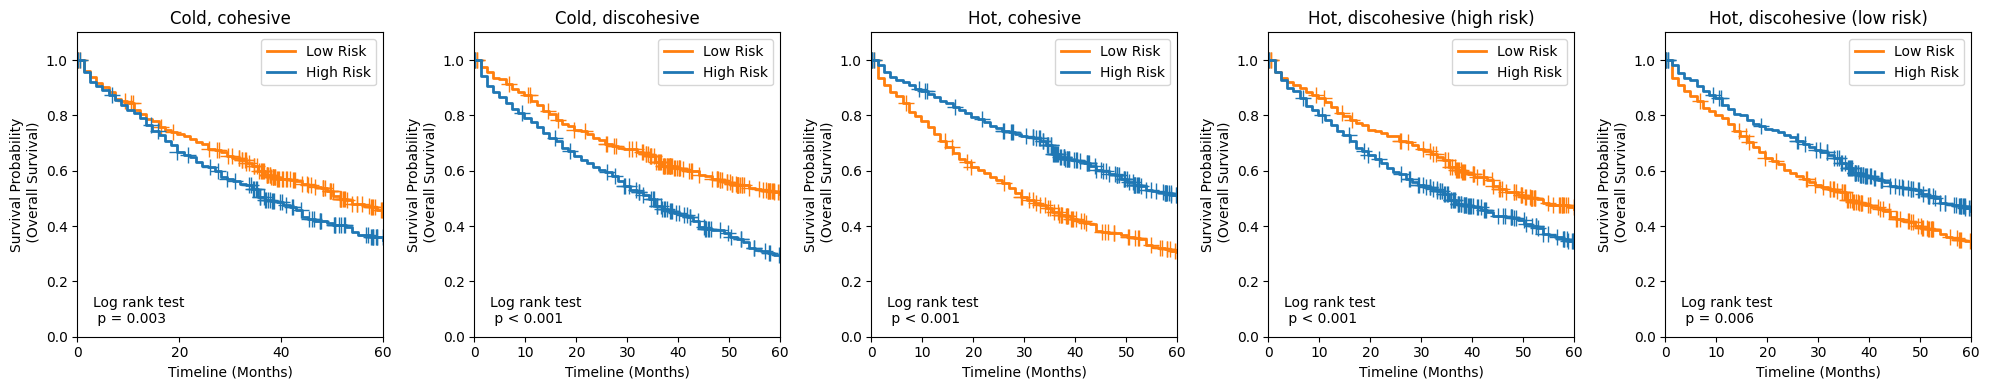

In [21]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20,4))
axs = axs.flatten()

for i, col in enumerate(median_dict.keys()):
    plot_km_two_groups(complete_sample_rep,
                       event_ind_field='os_event_ind',
                       event_data_field='os_event_data', 
                       group_col=f'{col} high',
                       max_months=60,
                       add_counts=False,
                       ci_show=False,
                       title=col,
                       ax=axs[i])

p = 0.066
p = 0.022
p = 0.033
p = 0.065
p = 0.625


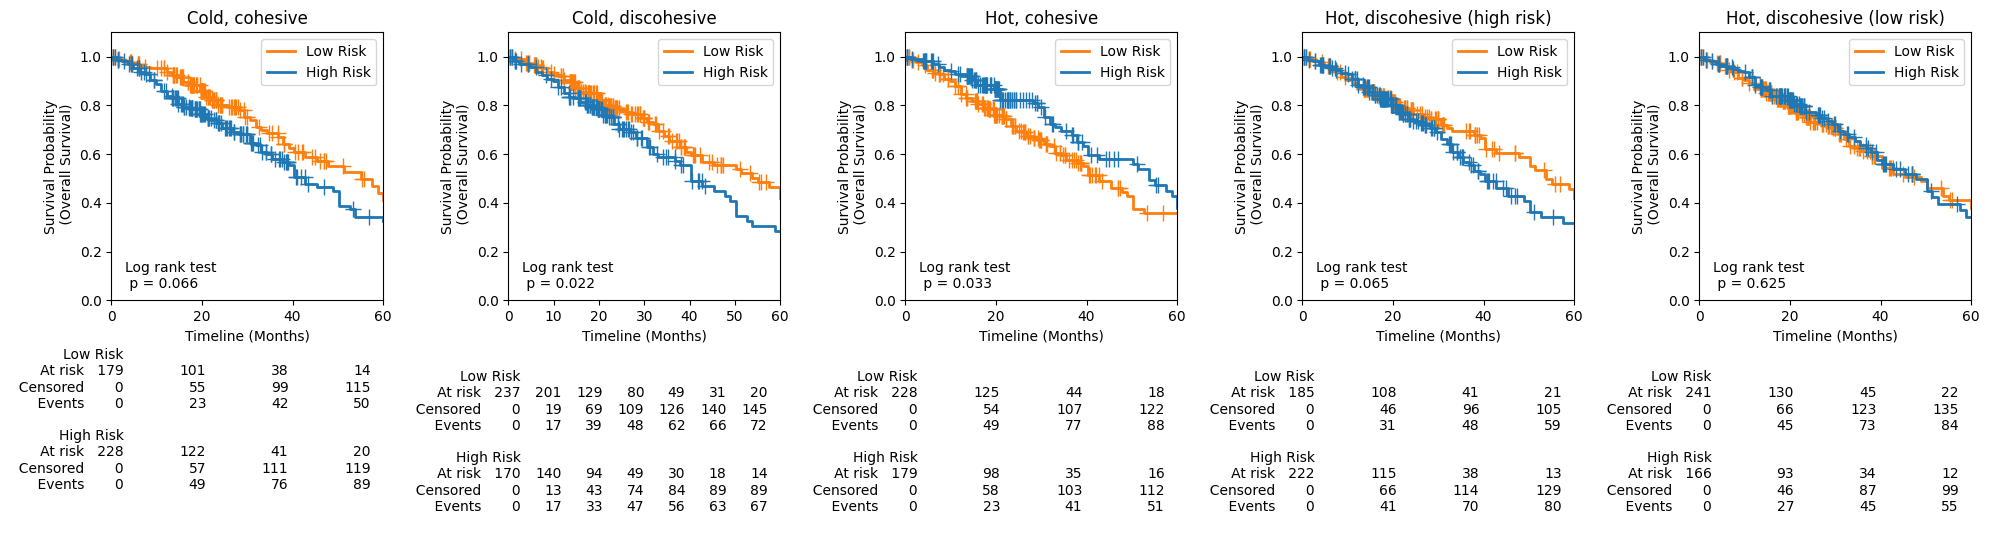

In [22]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20,5.5))
axs = axs.flatten()

for i, col in enumerate(median_dict.keys()):
    plot_km_two_groups(additional_sample_rep,
                       event_ind_field='os_event_ind',
                       event_data_field='os_event_data', 
                       group_col=f'{col} high',
                       max_months=60,
                       add_counts=True,
                       ci_show=False,
                       title=col,
                       ax=axs[i])
    
plt.tight_layout()
plt.show()

### Cox

In [23]:
if os.path.isfile(os.path.join(main_path, 'data/cohesion-superclusters/complete_sample_rep_cox.csv')):
    complete_sample_rep_cox = pd.read_csv(os.path.join(main_path, 'data/cohesion-superclusters/complete_sample_rep_cox.csv'), index_col=0)
else:

    complete_sample_rep_cox = generate_frequency_vector(complete_df, matching_field='samples', groupby='leiden_2.5', leiden_clusters=list(malignant_clusters)+[16], transform=True)

    complete_melt =  pd.melt(complete_sample_rep_cox, id_vars='samples', value_vars=list(malignant_clusters)+[16], var_name='cluster', value_name='perc')
    complete_melt['supercluster'] = complete_melt['cluster'].apply(lambda x: assign_supercluster(f'HPC {x}'))
    complete_melt = complete_melt[complete_melt['supercluster'] != 'Unknown']
    complete_melt = pd.pivot_table(complete_melt, values='perc', index=['samples'], columns='supercluster', aggfunc='mean')

    complete_sample_rep_cox = complete_melt.merge(clinpath_mo[['samples', 'male', 'age', 'stage_num', 'os_event_ind', 'os_event_data']], on='samples', how='left')

    complete_sample_rep_cox = complete_sample_rep_cox.merge(patterns_samples[['samples', 'iaslc_grade']], on='samples')
    non_mucinous_samples = clinpath[clinpath['2015 WHO Classification'] != 'Invasive mucinous adenocarcinoma (IMA)']['samples']

    complete_sample_rep_cox = complete_sample_rep_cox[complete_sample_rep_cox['samples'].isin(non_mucinous_samples)].reset_index()
    complete_sample_rep_cox['stage_num'] = complete_sample_rep_cox['stage_num'].map({1:0, 2:1, 3:1})
    complete_sample_rep_cox['stage_num'] = complete_sample_rep_cox['stage_num'].astype('category')
    complete_sample_rep_cox['iaslc_grade'] = complete_sample_rep_cox['iaslc_grade'].map({1:0, 2:1, 3:1})
    complete_sample_rep_cox['iaslc_grade'] = complete_sample_rep_cox['iaslc_grade'].astype('category')
    complete_sample_rep_cox.to_csv(os.path.join(main_path, 'data/cohesion-superclusters/complete_sample_rep_cox.csv'))

complete_sample_rep_cox['stage_num'] = pd.Categorical(complete_sample_rep_cox['stage_num'], ordered=True)
complete_sample_rep_cox['iaslc_grade'] = pd.Categorical(complete_sample_rep_cox['iaslc_grade'], ordered=True)

complete_sample_rep_cox.info()

<class 'pandas.core.frame.DataFrame'>
Index: 941 entries, 0 to 940
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   index                         941 non-null    int64   
 1   samples                       941 non-null    object  
 2   Cold, cohesive                941 non-null    float64 
 3   Cold, discohesive             941 non-null    float64 
 4   Hot, cohesive                 941 non-null    float64 
 5   Hot, discohesive (high risk)  941 non-null    float64 
 6   Hot, discohesive (low risk)   941 non-null    float64 
 7   male                          941 non-null    int64   
 8   age                           941 non-null    int64   
 9   stage_num                     788 non-null    category
 10  os_event_ind                  941 non-null    int64   
 11  os_event_data                 941 non-null    float64 
 12  iaslc_grade                   941 non-null    category


In [24]:
if os.path.isfile(os.path.join(main_path, 'data/cohesion-superclusters/additional_sample_rep_cox.csv')):
    additional_sample_rep_cox = pd.read_csv(os.path.join(main_path, 'data/cohesion-superclusters/additional_sample_rep_cox.csv'), index_col=0)
else:
    additional_sample_rep_cox = generate_frequency_vector(additional_df, matching_field='samples', groupby='leiden_2.5', leiden_clusters=list(malignant_clusters)+[16], transform=True)

    additional_melt =  pd.melt(additional_sample_rep_cox, id_vars='samples', value_vars=list(malignant_clusters)+[16], var_name='cluster', value_name='perc')
    additional_melt['supercluster'] = additional_melt['cluster'].apply(lambda x: assign_supercluster(f'HPC {x}'))
    additional_melt = additional_melt[additional_melt['supercluster'] != 'Unknown']
    additional_melt = pd.pivot_table(additional_melt, values='perc', index=['samples'], columns='supercluster', aggfunc='mean')

    additional_sample_rep_cox = additional_melt.merge(TCGA_survival, on='samples', how='left').dropna().reset_index()
    additional_sample_rep_cox['iaslc_grade'] = additional_sample_rep_cox['iaslc_grade'].map({1:0, 2:1, 3:1})
    additional_sample_rep_cox['stage_num'] = additional_sample_rep_cox['stage_num'].map({1:0, 2:1, 3:1})

    additional_sample_rep_cox.to_csv(os.path.join(main_path, 'data/cohesion-superclusters/additional_sample_rep_cox.csv'))

additional_sample_rep_cox = additional_sample_rep_cox.rename(columns={'sex':'male'})
additional_sample_rep_cox['stage_num'] = pd.Categorical(additional_sample_rep_cox['stage_num'], ordered=True)
additional_sample_rep_cox['iaslc_grade'] = pd.Categorical(additional_sample_rep_cox['iaslc_grade'], ordered=True)
additional_sample_rep_cox.info()

<class 'pandas.core.frame.DataFrame'>
Index: 408 entries, 0 to 407
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   index                         408 non-null    int64   
 1   samples                       408 non-null    object  
 2   Cold, cohesive                408 non-null    float64 
 3   Cold, discohesive             408 non-null    float64 
 4   Hot, cohesive                 408 non-null    float64 
 5   Hot, discohesive (high risk)  408 non-null    float64 
 6   Hot, discohesive (low risk)   408 non-null    float64 
 7   age                           408 non-null    float64 
 8   male                          408 non-null    float64 
 9   os_event_ind                  408 non-null    float64 
 10  os_event_data                 408 non-null    float64 
 11  stage_num                     408 non-null    category
 12  iaslc_grade                   408 non-null    category


In [25]:
median_dict_cox = dict()

for col in ['Cold, cohesive', 'Cold, discohesive', 'Hot, cohesive', 'Hot, discohesive (high risk)', 'Hot, discohesive (low risk)']:
    median = complete_sample_rep_cox[col].median()
    median_dict_cox[col] = median

for col in median_dict_cox.keys():
    complete_sample_rep_cox[f'{col} high'] = complete_sample_rep_cox[col].apply(lambda x: 1 if x > median_dict_cox[col] else 0)
    additional_sample_rep_cox[f'{col} high'] = additional_sample_rep_cox[col].apply(lambda x: 1 if x > median_dict_cox[col] else 0)

p < 0.001
p < 0.001
p < 0.001
p < 0.001
p = 0.059


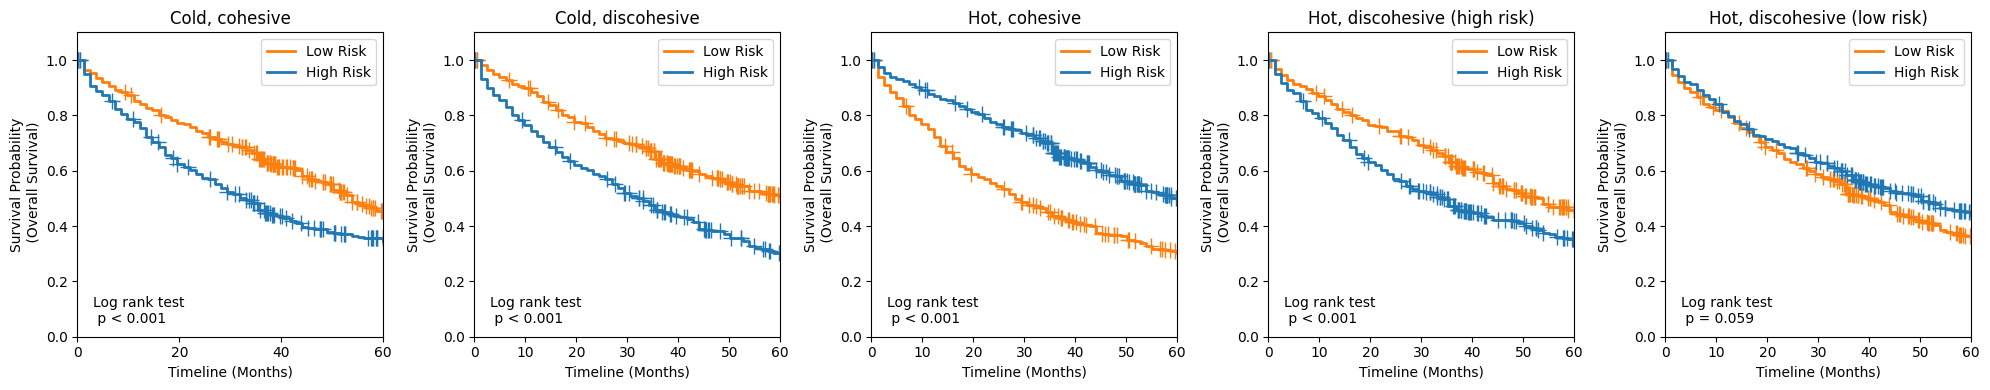

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20,4))
axs = axs.flatten()

for i, col in enumerate(median_dict_cox.keys()):
    plot_km_two_groups(complete_sample_rep_cox,
                       event_ind_field='os_event_ind',
                       event_data_field='os_event_data', 
                       group_col=f'{col} high',
                       max_months=60,
                       add_counts=False,
                       ci_show=False,
                       title=col,
                       ax=axs[i])

p = 0.566
p = 0.001
p = 0.049
p = 0.115
p = 0.078


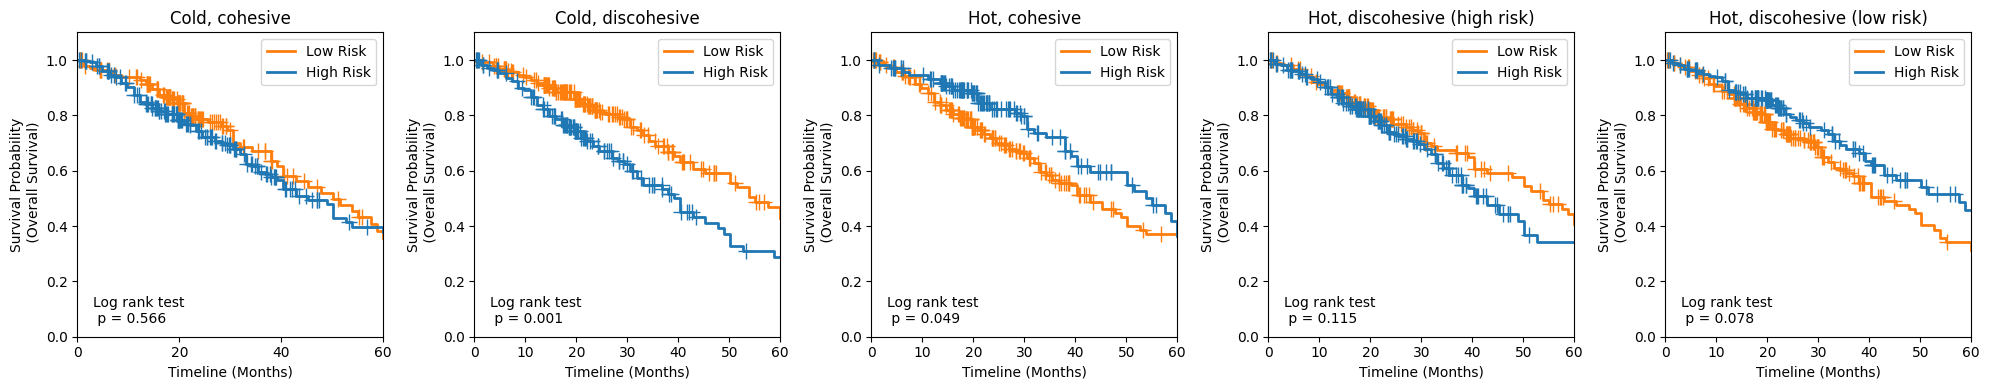

In [27]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20,4))
axs = axs.flatten()

for i, col in enumerate(median_dict_cox.keys()):
    plot_km_two_groups(additional_sample_rep_cox,
                       event_ind_field='os_event_ind',
                       event_data_field='os_event_data', 
                       group_col=f'{col} high',
                       max_months=60,
                       add_counts=False,
                       ci_show=False,
                       title=col,
                       ax=axs[i])

In [28]:
from sklearn.model_selection import KFold

data_dict = dict()
feature_cols = list(median_dict.keys()) + ['age', 'stage_num', 'iaslc_grade']
# feature_cols = [f'{col} high' for col in median_dict.keys()]

complete_sample_rep_cox = complete_sample_rep_cox.dropna().reset_index()
additional_sample_rep_cox = additional_sample_rep_cox.dropna().reset_index()

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(complete_sample_rep_cox)):
    data_dict[fold] = dict()
    data_dict[fold]['train_X'] = complete_sample_rep_cox.loc[train_idx][feature_cols]
    data_dict[fold]['train_all'] = complete_sample_rep_cox.loc[train_idx]
    data_dict[fold]['test_X'] = complete_sample_rep_cox.loc[test_idx][feature_cols]
    data_dict[fold]['test_all'] = complete_sample_rep_cox.loc[test_idx] 
    data_dict[fold]['additional_X'] = additional_sample_rep_cox.loc[:, feature_cols]
    data_dict[fold]['additional_all'] = additional_sample_rep_cox

In [29]:
def train_cox(data_dict, fold,  penalizer, l1_ratio, event_data_col, event_ind_col, cols_to_include, additional_flag=True, robust=True, save_path=None):
    train, test = data_dict[fold]['train_all'], data_dict[fold]['test_all']
    if additional_flag:
        additional = data_dict[fold]['additional_all']

    cols_to_include_ = cols_to_include + [event_data_col, event_ind_col]

    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)

    try:
        cph.fit(train[cols_to_include_], event_data_col, event_ind_col, show_progress=False)
    except ValueError:
        train = train[~train[cols_to_include_].isna()]
        cph.fit(train, event_data_col, event_ind_col, show_progress=False, robust=robust)

    summary = cph.summary
    summary = summary.sort_values(by='coef', ascending=True)

    predictions = dict()
    predictions['train'] = cph.predict_partial_hazard(train)
    predictions['test'] = cph.predict_partial_hazard(test)
    predictions['additional'] = cph.predict_partial_hazard(additional)

    train_ci = concordance_index(train[event_data_col], -cph.predict_partial_hazard(train), train[event_ind_col])
    test_ci = concordance_index(test[event_data_col], -cph.predict_partial_hazard(test), test[event_ind_col])
    if additional_flag:
        additional_ci = concordance_index(additional[event_data_col], -cph.predict_partial_hazard(additional), additional[event_ind_col])
    else:
        additional_ci = 0

    if save_path is not None:
        summary.to_csv(os.path.join(save_path, f'{event_ind_col}_fold_{fold}.csv'))
    print(f'Fold {fold} Alpha {penalizer:.3f}\tC-index (Train/test/additional): {train_ci:.3f}/{test_ci:.3f}/{additional_ci:.3f}')

    return summary, [train_ci, test_ci, additional_ci], predictions, cph

In [30]:
event_data_field = 'os_event_data'
event_ind_field = 'os_event_ind'

warnings.filterwarnings("ignore")
alphas    = 10.0 ** np.linspace(-4, 4, 50)
l1_ratios = [0]
num_folds = 5
cols_to_include = list(feature_cols)

for l1_ratio in l1_ratios:
	print('L1 Penalty', l1_ratio)
	cox_data = list()
	alpha_path = os.path.join(main_cluster_path, f'{meta_folder}_{groupby}_l1ratio_{str(l1_ratio).replace(".", "p")}_mintiles_{str(min_tiles)}_{event_ind_field}_{str(generate_timestamp())}')
	if not os.path.exists(alpha_path): 
		os.makedirs(alpha_path)
	groupby     = 'leiden_%s' % resolution
	alphas_df   = list()
	for alpha in alphas:
		print('\n\t\t', 'Alpha', alpha)

		summaries = list()
		c_indexes = list()

		for fold in range(num_folds):
			summary, ci, _, _ = train_cox(data_dict=data_dict, fold=fold, penalizer=alpha, l1_ratio=l1_ratio, event_ind_col=event_ind_field, event_data_col=event_data_field, cols_to_include=cols_to_include, additional_flag=True, save_path=None)
			summaries.append(summary)
			c_indexes.append(ci)

		cis_df = pd.DataFrame(c_indexes, columns=['train', 'test', 'additional'])
		cis_df['alpha'] = alpha
		cis_df = cis_df.reset_index()
		cis_df.rename(columns={'index':'fold'}, inplace=True)
		alphas_df.append(cis_df)

	all_cis_df = pd.concat(alphas_df)
	all_cis_df.to_csv(os.path.join(alpha_path, 'c_indexes.csv'))

L1 Penalty 0

		 Alpha 0.0001
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.688/0.635/0.665
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.674/0.696/0.676
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.671/0.715/0.669
Fold 3 Alpha 0.000	C-index (Train/test/additional): 0.677/0.687/0.670
Fold 4 Alpha 0.000	C-index (Train/test/additional): 0.691/0.627/0.664

		 Alpha 0.00014563484775012445
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.688/0.635/0.665
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.674/0.696/0.676
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.671/0.715/0.669
Fold 3 Alpha 0.000	C-index (Train/test/additional): 0.677/0.687/0.670
Fold 4 Alpha 0.000	C-index (Train/test/additional): 0.691/0.627/0.664

		 Alpha 0.00021209508879201905
Fold 0 Alpha 0.000	C-index (Train/test/additional): 0.688/0.635/0.665
Fold 1 Alpha 0.000	C-index (Train/test/additional): 0.674/0.696/0.676
Fold 2 Alpha 0.000	C-index (Train/test/additional): 0.671/0.715/

In [31]:
def get_best_alpha(alpha_path):
    try:
        results_path = os.path.join(alpha_path, 'c_indexes.csv')
        results = pd.read_csv(results_path)
    except:
        results = alpha_path

    alphas = np.unique(results['alpha'].values)
    mean_cis = list()

    for alpha in alphas:
        subset = results[results['alpha'] == alpha]
        train = subset['train'].mean()
        test = subset['test'].mean()
        additional = subset['additional'].mean()
        if additional > 0:
            mean_cis.append(np.mean((train, test, additional)))
        else:
            mean_cis.append((train, test))

    max_ci = max(mean_cis)
    alpha_index = mean_cis.index(max_ci)

    best_alpha = alphas[alpha_index]
    
    return best_alpha
    
best_alpha = get_best_alpha(alpha_path=alpha_path)
best_alpha

0.0596362331659464

In [32]:
def get_high_low_risks(data_dict, predictions, fold, alpha_path, additional_flag=True, q_buckets=2):
    fold_data_all = dict()
    fold_data_all['train'] = data_dict[fold]['train_all']
    fold_data_all['test'] = data_dict[fold]['test_all']
    if additional_flag:
        fold_data_all['additional'] = data_dict[fold]['additional_all']
        sets = ['train', 'test', 'additional']
    else:
        sets = ['train', 'test']

    high_low = list()

    for set_name in sets:
        current_predictions = predictions[set_name].copy(deep=True)
        current_data = fold_data_all[set_name].copy(deep=True)
        current_data['hazard'] = current_predictions

        if set_name == 'train':
            if q_buckets == 2:
                hazard_cutoff = np.median(current_predictions)
            else:
                cutoffs = create_risk_buckets(predictions=predictions, num_groups=q_buckets)
        
        if q_buckets == 2:
            current_data[f'h_bin_{fold}'] = (current_data['hazard'] > hazard_cutoff) * 1
        else:
            current_data[f'h_bin_{fold}'] = pd.cut(current_data['hazard'], bins=[-np.inf] + list(cutoffs) + [np.inf],
                                                   labels=[i for i in range(len(list(cutoffs))+1)])

        current_data['original_set'] = set_name
        high_low.append(current_data)
    
    high_low_frame = pd.concat(high_low)
    high_low_frame['fold'] = fold
    high_low_frame.to_csv(os.path.join(alpha_path, f'high_low_fold_{fold}.csv'))
    
    return high_low_frame

In [33]:
warnings.filterwarnings("ignore")

l1_ratio = 0

risk_groups = [pd.DataFrame(), pd.DataFrame()]
additional_risk = pd.DataFrame()
cis_folds = list()
estimators = list()

summaries = list()
c_indexes = list()
cph_models = list()

for fold in range(num_folds):
    summary, ci, predictions, cph_model = train_cox(data_dict=data_dict, fold=fold, penalizer=best_alpha, l1_ratio=l1_ratio, event_ind_col=event_ind_field, event_data_col=event_data_field, cols_to_include=cols_to_include, additional_flag=True, save_path=alpha_path)
    summary.index = [f'HPC {c}' for c in summary.index.values]
    summary.index.name = 'covariate'
    # high_low_frame = get_high_low_risks(data_dict=data_dict, predictions=predictions, fold=fold, alpha_path=alpha_path, q_buckets=2)
    # forest_plots(frame=summary, scale_to_plot='exp', fold=fold, event_ind_col=event_ind_field, save_path=alpha_path)
    summaries.append(summary)
    c_indexes.append(ci)
    cph_models.append(cph_model)

    # print('\t\tFold', fold, 'Alpha', np.round(best_alpha,2), 'Train/Test/Additional C-Index:', '/'.join([str(i) for i in c_indexes[fold]]))
    

Fold 0 Alpha 0.060	C-index (Train/test/additional): 0.687/0.639/0.666
Fold 1 Alpha 0.060	C-index (Train/test/additional): 0.673/0.699/0.676
Fold 2 Alpha 0.060	C-index (Train/test/additional): 0.671/0.716/0.669
Fold 3 Alpha 0.060	C-index (Train/test/additional): 0.676/0.690/0.673
Fold 4 Alpha 0.060	C-index (Train/test/additional): 0.691/0.627/0.666


In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_forest(
    feature_names,
    estimates,
    ci_lower,
    ci_upper,
    p_values,
    *,
    reference=1.0,
    x_label="Hazard ratio (95% CI)",
    marker_kwargs=None,
    error_kwargs=None,
    table_headers=("95% CI", "p"),
    figsize=None,
):
    feature_names = list(feature_names)
    n_features = len(feature_names)

    estimates = np.asarray(estimates, dtype=float)
    ci_lower = np.asarray(ci_lower, dtype=float)
    ci_upper = np.asarray(ci_upper, dtype=float)
    p_values = np.asarray(p_values, dtype=float)

    if not (len(estimates) == len(ci_lower) == len(ci_upper) == len(p_values) == n_features):
        raise ValueError("All input arrays must match feature_names length.")

    if figsize is None:
        figsize = (7, 0.45 * n_features + 1.5)

    default_marker = {"fmt": "s", "color": "black", "markersize": 6, "mec": "black"}
    default_error = {"ecolor": "black", "elinewidth": 1.4, "capsize": 3, "capthick": 1.2}
    marker_kwargs = {**default_marker, **(marker_kwargs or {})}
    error_kwargs = {**default_error, **(error_kwargs or {})}

    fig, axes_arr = plt.subplots(
        ncols=2,
        sharey=True,
        figsize=figsize,
        gridspec_kw={"width_ratios": [0.7, 0.3]},
    )
    ax_forest, ax_table = axes_arr

    y_positions = np.arange(n_features)[::-1]

    # Middle forest plot
    error_offsets = np.vstack([estimates - ci_lower, ci_upper - estimates])
    ax_forest.errorbar(estimates, y_positions, xerr=error_offsets, **marker_kwargs, **error_kwargs)
    ax_forest.axvline(reference, color="grey", linewidth=1.15, linestyle="--")
    ax_forest.set_xlabel(x_label)
    ax_forest.set_yticks(y_positions)
    ax_forest.set_yticklabels(feature_names)
    ax_forest.set_ylim(-0.5, n_features - 0.5)
    ax_forest.set_xlim([min(ci_lower) - 0.2, max(ci_upper) + 0.2])
    ax_forest.set_ylabel('Cluster')

    for ax in [ax_forest]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_visible(False)

    # Right: two-column text (CI | p-value)
    def format_interval(lo, hi):
        return f"({lo:.2f} – {hi:.2f})"

    def format_p(p):
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "<0.001"
        return f"{p:.3f}"

    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(-0.5, n_features - 0.5)
    ax_table.axis("off")

    ci_x, p_x = 0.1, 0.75  # tweak to taste

    ax_table.text(ci_x, n_features - 0.3, table_headers[0], va="bottom", ha="center", fontsize=11, fontweight="bold")
    ax_table.text(p_x, n_features - 0.3, table_headers[1], va="bottom", ha="center", fontsize=11, fontweight="bold")

    for y, lo, hi, p in zip(y_positions, ci_lower, ci_upper, p_values):
        ax_table.text(ci_x, y, format_interval(lo, hi), va="center", ha="center", fontsize=10)
        ax_table.text(p_x, y, format_p(p), va="center", ha="center", fontsize=10)

    fig.tight_layout()
    return fig, {"forest": ax_forest, "table": ax_table}
    # return fig, {"labels": ax_labels, "forest": ax_forest, "table": ax_table}


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
HPC age,0.011459,1.011525,0.005296,0.001080,0.021839,1.001080,1.022079,0.0,2.163809,3.047900e-02,5.036041
HPC iaslc_grade,0.461997,1.587240,0.199818,0.070361,0.853633,1.072895,2.348162,0.0,2.312088,2.077284e-02,5.589158
HPC stage_num,0.599015,1.820325,0.103208,0.396731,0.801298,1.486956,2.228432,0.0,5.803969,6.476338e-09,27.202175
"HPC Hot, discohesive (low risk)",-0.181011,0.834426,0.059763,-0.298144,-0.063879,0.742195,0.938119,0.0,-3.028840,2.454947e-03,8.670092
"HPC Hot, cohesive",-0.088760,0.915065,0.093450,-0.271918,0.094399,0.761916,1.098998,0.0,-0.949809,3.422094e-01,1.547049
"HPC Hot, discohesive (high risk)",0.126131,1.134430,0.032968,0.061514,0.190747,1.063446,1.210153,0.0,3.825835,1.303295e-04,12.905549
"HPC Cold, cohesive",0.144590,1.155565,0.094171,-0.039982,0.329161,0.960807,1.389802,0.0,1.535397,1.246864e-01,3.003624
"HPC Cold, discohesive",0.257400,1.293562,0.077446,0.105609,0.409191,1.111387,1.505599,0.0,3.323615,8.885889e-04,10.136196


In [60]:
summary.index

Index(['HPC Hot, discohesive (low risk)', 'HPC Hot, cohesive', 'HPC age',
       'HPC Hot, discohesive (high risk)', 'HPC Cold, cohesive',
       'HPC Cold, discohesive', 'HPC iaslc_grade', 'HPC stage_num'],
      dtype='object', name='covariate')

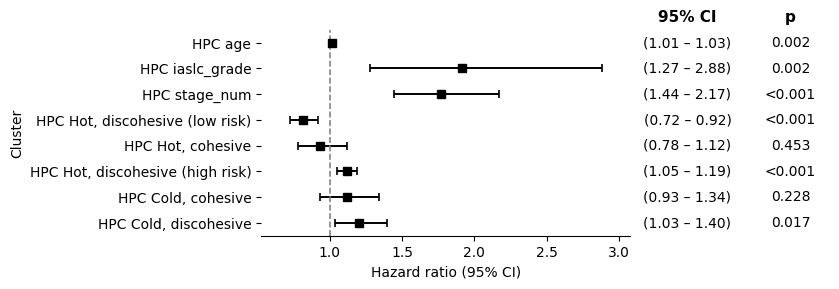

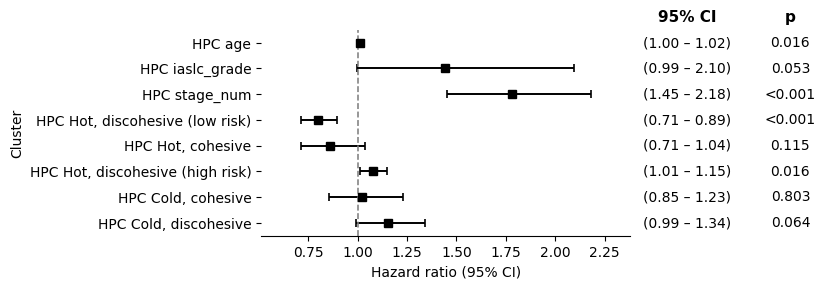

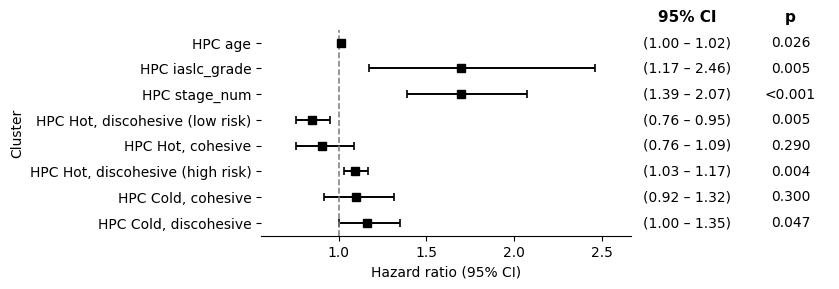

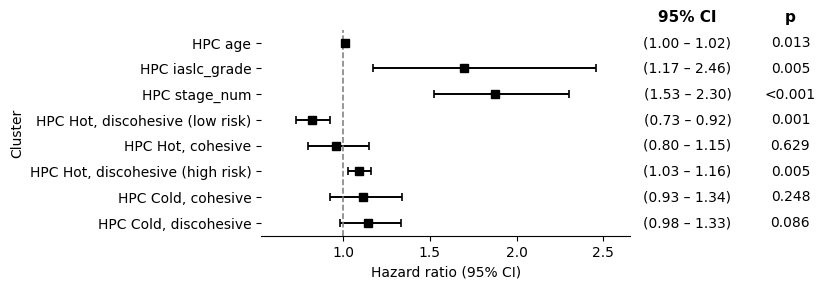

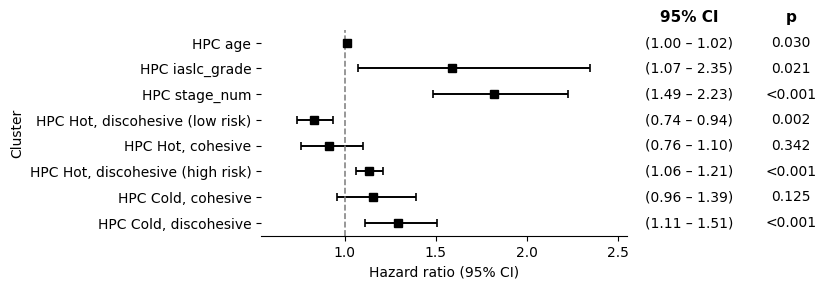

In [74]:
results_dir = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/rapids_2p5m/superclusters_os_age_grade_stage_bins')

for i, summary in enumerate(summaries):

    summary = summary.reindex(index=['HPC age', 'HPC iaslc_grade', 'HPC stage_num', 
                       'HPC Hot, discohesive (low risk)', 'HPC Hot, cohesive',
       'HPC Hot, discohesive (high risk)', 'HPC Cold, cohesive',
       'HPC Cold, discohesive',])

    plot_forest(feature_names=summary.index,
                estimates=summary['exp(coef)'],
                ci_lower=summary['exp(coef) lower 95%'],
                ci_upper=summary['exp(coef) upper 95%'],
                p_values=summary['p'],
                figsize=(8.5,3.))
    
    plt.savefig(os.path.join(main_path, results_dir, f'os_fold_{i}.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

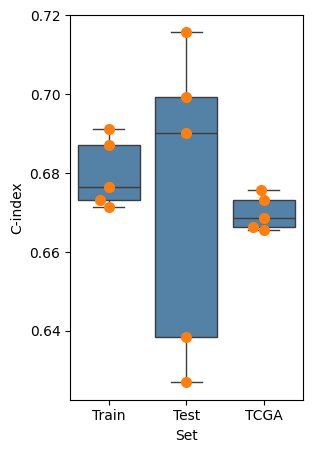

In [56]:
ci_df = pd.DataFrame(c_indexes, columns=['Train', 'Test', 'TCGA'])

fig, ax = plt.subplots(figsize=(3,5))
sns.boxplot(ci_df, color='steelblue', ax=ax)
sns.swarmplot(ci_df, color='tab:orange', s=8, ax=ax)
ax.set_xlabel('Set')
ax.set_ylabel('C-index')

plt.savefig(os.path.join(main_path, results_dir, f'c_indexes.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)